In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import transformers
from umap import UMAP

In [2]:
emotions = load_dataset("emotion")

Using the latest cached version of the dataset since emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\98922\.cache\huggingface\datasets\emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Mon Feb  9 18:08:02 2026).


In [3]:
from transformers import AutoTokenizer

model_ckpt = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [4]:
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

In [5]:
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

In [6]:
from transformers import AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

In [7]:
text = 'this is a test'
inputs = tokenizer(text, return_tensors="pt")
print(f"Inputs Tensor Shape: {inputs["input_ids"].size()}")

Inputs Tensor Shape: torch.Size([1, 6])


In [8]:
inputs = {k:v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)

print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]],
       device='cuda:0'), hidden_states=None, attentions=None)


In [9]:
outputs.last_hidden_state.size()

torch.Size([1, 6, 768])

In [10]:
outputs.last_hidden_state[:,0].size()

torch.Size([1, 768])

In [9]:
def extract_hidden_state(batch):
    inputs = {
        k:v.to(device) for k,v in batch.items() if k in tokenizer.model_input_names
             }
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state

    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

In [10]:
emotions_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

In [11]:
emotions_hidden = emotions_encoded.map(extract_hidden_state, batched=True)

In [12]:
emotions_hidden["train"].column_names

['text', 'label', 'input_ids', 'attention_mask', 'hidden_state']

In [13]:
X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_val = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_val = np.array(emotions_hidden["validation"]["label"])
print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(16000, 768) (2000, 768)
(16000,) (2000,)


In [14]:
X_scaled = MinMaxScaler().fit_transform(X_train)
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
df_emb = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_emb["label"] = y_train
df_emb.head()

,X,Y,label
0,4.149223,3.251186,0
1,-3.115832,3.616318,0
2,5.143628,6.708832,3
3,-2.954770,6.000308,2
4,-3.572644,5.537618,3


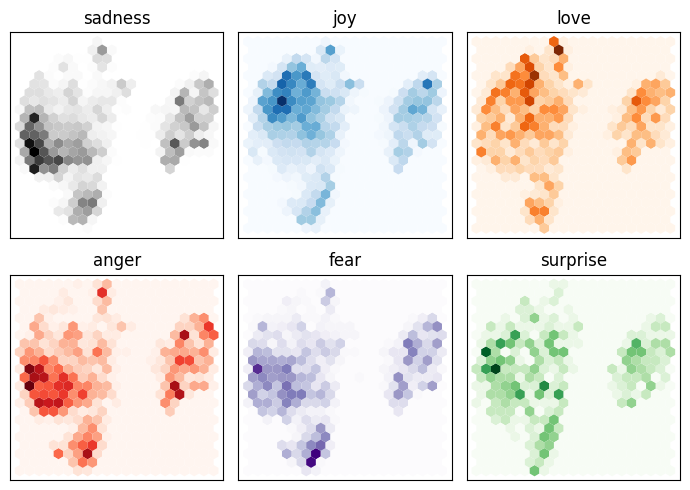

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(7, 5))
axes = axes.flatten()
cmaps = ["Greys", "Blues", "Oranges", "Reds", "Purples", "Greens"]
labels = emotions["train"].features["label"].names

for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_emb_sub = df_emb.query(f"label == {i}")
    axes[i].hexbin(df_emb_sub["X"], df_emb_sub["Y"], cmap=cmap, gridsize=20, linewidth=(0,))
    axes[i].set_title(label)
    axes[i].set_xticks([]) , axes[i].set_yticks([])

plt.tight_layout()
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)
lr_clf.score(X_val, y_val)

0.635

In [31]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_val, y_val)

0.352

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_preds, y_ture, labels):
    cm = confusion_matrix(y_preds, y_ture, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Reds", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized Confusion Matrix")
    plt.show()

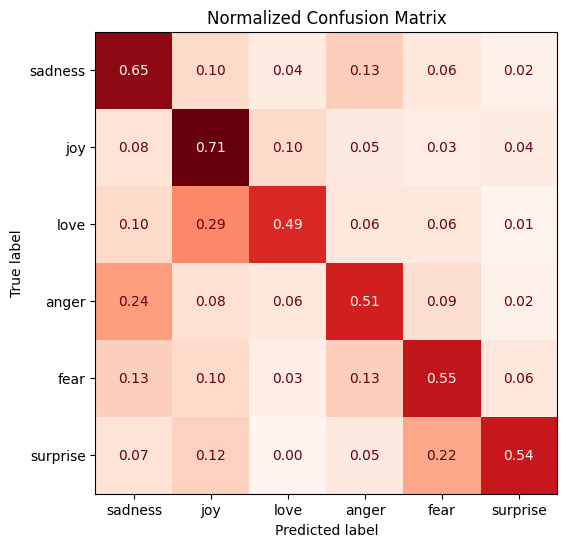

In [20]:
y_preds = lr_clf.predict(X_val)
plot_confusion_matrix(y_preds, y_val, labels)

In [21]:
from huggingface_hub import notebook_login
notebook_login()

In [22]:
from transformers import AutoModelForSequenceClassification
num_labels = 6
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt, num_labels=num_labels)
         .to(device))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
from sklearn.metrics import accuracy_score, f1_score
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average='weighted')
    accuracy = accuracy_score(labels, preds)
    return {"accuracy": accuracy, "f1": f1}

In [24]:
from transformers import Trainer, TrainingArguments
batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion"
training_args = TrainingArguments(
    output_dir=model_name,
    num_train_epochs=2,
    learning_rate=2e-5,
    logging_steps=logging_steps,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy="epoch",
    disable_tqdm=False,
    push_to_hub=True,
    log_level="error"
)

In [25]:
trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded["validation"],
                  processing_class=tokenizer)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.845000,0.313744,0.904000,0.902708
2,0.249400,0.216965,0.927500,0.927507


TrainOutput(global_step=500, training_loss=0.547237564086914, metrics={'train_runtime': 453.0989, 'train_samples_per_second': 70.625, 'train_steps_per_second': 1.104, 'total_flos': 720342861696000.0, 'train_loss': 0.547237564086914, 'epoch': 2.0})

In [26]:
preds_output = trainer.predict(emotions_encoded["validation"])
preds_output.metrics

{'test_loss': 0.2169651836156845,
 'test_accuracy': 0.9275,
 'test_f1': 0.927506857902366,
 'test_runtime': 9.5981,
 'test_samples_per_second': 208.375,
 'test_steps_per_second': 3.334}

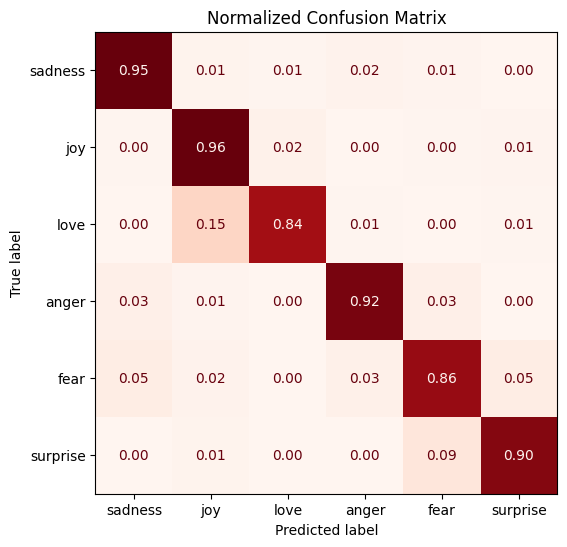

In [28]:
y_preds = np.argmax(preds_output.predictions, axis=1)
plot_confusion_matrix(y_preds, y_val, labels)

In [74]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

In [75]:
from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):
    inputs = {k:v.to(device) for k, v in batch.items()
              if k in tokenizer.model_input_names}
    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device), reduction="none")

    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

In [76]:
emotions_encoded.set_format(
    "torch", columns=["input_ids", "attention_mask", "label"]
)
emotions_encoded["validation"] = emotions_encoded["validation"].map(
    forward_pass_with_label, batched=True, batch_size=16
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [77]:
emotions_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = df_test["predicted_label"].apply(label_int2str)

In [78]:
df_test.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
1963,i called myself pro life and voted for perry w...,joy,sadness,5.496512
1274,i am going to several holiday parties and i ca...,joy,sadness,5.407252
765,i feel super awkward and out of place right now,joy,sadness,5.320174
882,i feel badly about reneging on my commitment t...,love,sadness,5.295076
1950,i as representative of everything thats wrong ...,surprise,sadness,5.275485
1870,i guess i feel betrayed because i admired him ...,joy,sadness,5.261806
465,i would eventually go in to these stores but i...,joy,fear,5.038819
1801,i feel that he was being overshadowed by the s...,love,sadness,4.956220
1500,i guess we would naturally feel a sense of lon...,anger,sadness,4.915220
1111,im lazy my characters fall into categories of ...,joy,fear,4.753544


In [79]:
df_test.sort_values("loss", ascending=True).head(10)

,text,label,predicted_label,loss
1873,i feel practically virtuous this month i have ...,joy,joy,0.016896
723,i was able to go to a st party i am back feeli...,joy,joy,0.017094
1884,i don t exactly feel sociable still,joy,joy,0.017272
1205,i log on feeling vaguely sociable and after a ...,joy,joy,0.017432
1263,i feel this way about blake lively,joy,joy,0.017436
1154,i love feeling carefree and without all these ...,joy,joy,0.017443
1619,i sat in the car and read my book which suited...,joy,joy,0.017493
632,i feel he is an terrific really worth bet,joy,joy,0.017631
262,i feel like its one of the most valuable tools...,joy,joy,0.017676
1137,i think i may be feeling sociable,joy,joy,0.017706


In [81]:
trainer.push_to_hub(commit_message="My first Transformers Training Completed !")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...finetuned-emotion\training_args.bin: 100%|##########| 5.78kB / 5.78kB            

  ...finetuned-emotion\model.safetensors:  13%|#2        | 33.6MB /  268MB            

CommitInfo(commit_url='https://huggingface.co/a1mohamadd/distilbert-base-uncased-finetuned-emotion/commit/946a9cd5742f9bdee0dff407ebf3951b16147cbf', commit_message='My first Transformers Training Completed !', commit_description='', oid='946a9cd5742f9bdee0dff407ebf3951b16147cbf', pr_url=None, repo_url=RepoUrl('https://huggingface.co/a1mohamadd/distilbert-base-uncased-finetuned-emotion', endpoint='https://huggingface.co', repo_type='model', repo_id='a1mohamadd/distilbert-base-uncased-finetuned-emotion'), pr_revision=None, pr_num=None)

In [82]:
from transformers import pipeline
model_id = "a1mohamadd/distilbert-base-uncased-finetuned-emotion"
classifier = pipeline("text-classification", model=model_id)

config.json:   0%|          | 0.00/871 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [83]:
custom_tweet = "I saw that movie last night and its was nice to watch it"
preds = classifier(custom_tweet, return_all_scores=True)

C:\Users\98922\ai-env\Lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


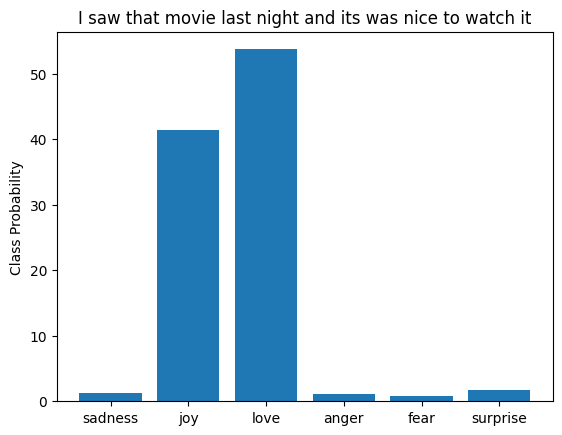

In [85]:
preds_df = pd.DataFrame(preds[0])
plt.bar(labels, 100 * preds_df["score"], color="C0")
plt.title(f"{custom_tweet}")
plt.ylabel("Class Probability")
plt.show()